start
/kaggle/working/coin_dataset/train → moved 1096 images
/kaggle/working/coin_dataset/valid → moved 161 images
/kaggle/working/coin_dataset/test → moved 305 images
✅ Unlabeled images moved successfully!
Train images      : 6221
Validation images : 897
Test images       : 1788
Classes (6)    : ['0', '1', '2', '3', '4', '5']

🖥️  Using device: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 184MB/s]


Downloading: "https://download.pytorch.org/models/shufflenetv2_x1-5666bf0f80.pth" to /root/.cache/torch/hub/checkpoints/shufflenetv2_x1-5666bf0f80.pth


100%|██████████| 8.79M/8.79M [00:00<00:00, 117MB/s]


📐 Teacher params : 11,179,590
📐 Student params : 1,791,720
   (of which CustomHead) : 264,198
   (of which CBAM total) : 35,326
   (of which Adapter)    : 238,592
🔗 Teacher layer4 hook registered.

  PHASE 1 — Training Teacher (ResNet-18)


[Teacher] Epoch 001/100 | Train Loss: 0.5357  Acc: 0.8021 | Val Loss: 1.0456  Acc: 0.7592
[Teacher] Epoch 002/100 | Train Loss: 0.2034  Acc: 0.9299 | Val Loss: 0.3555  Acc: 0.8896
[Teacher] Epoch 003/100 | Train Loss: 0.1925  Acc: 0.9333 | Val Loss: 0.1965  Acc: 0.9331
[Teacher] Epoch 004/100 | Train Loss: 0.1133  Acc: 0.9611 | Val Loss: 0.0344  Acc: 0.9889
[Teacher] Epoch 005/100 | Train Loss: 0.0673  Acc: 0.9760 | Val Loss: 0.2358  Acc: 0.9119
[Teacher] Epoch 006/100 | Train Loss: 0.0941  Acc: 0.9675 | Val Loss: 0.0649  Acc: 0.9810
[Teacher] Epoch 007/100 | Train Loss: 0.0556  Acc: 0.9828 | Val Loss: 0.2311  Acc: 0.9532
[Teacher] Epoch 008/100 | Train Loss: 0.0797  Acc: 0.9752 | Val Loss: 0.1193  Acc: 0.9599
[Teacher] Epoch 009/100 | Train Loss: 0.0438  Acc: 0.9836 | Val Loss: 0.0418  Acc: 0.9855
[Teacher] Epoch 010/100 | Train Loss: 0.0502  Acc: 0.9859 | Val Loss: 0.2588  Acc: 0.9275
[Teacher] Epoch 011/100 | Train Loss: 0.0784  Acc: 0.9764 | Val Loss: 0.0331  Acc: 0.9922
[Teacher] 

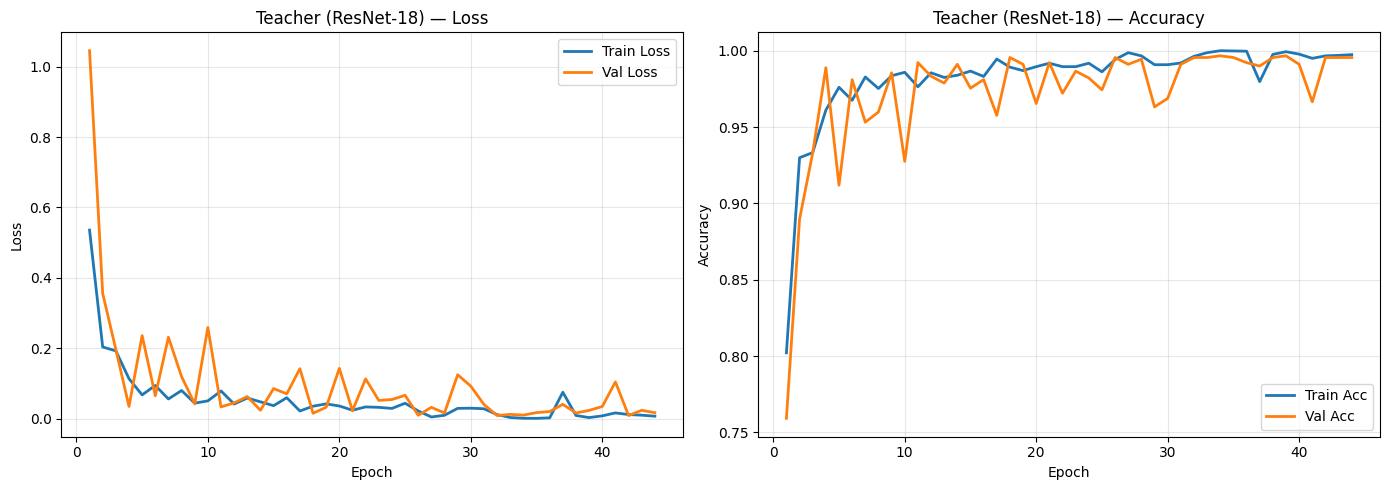

📊 Saved: /kaggle/working/teacher_curves.png


In [ ]:
# ============================================================
# KNOWLEDGE DISTILLATION: ResNet18 (Teacher) → ShuffleNet (Student)
# Student: CBAM + Feature Alignment Adapter + Custom Head
# Coin Classification Task
# ============================================================
print('start')
import os
import copy
import shutil
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import AdamW
from torch.optim.lr_scheduler import CosineAnnealingLR

import torchvision.models as models
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

from sklearn.metrics import (
    confusion_matrix, accuracy_score,
    precision_score, recall_score, f1_score, classification_report
)

# ============================================================
# 1. DATASET SETUP (unchanged)
# ============================================================

IMG_SIZE   = 224
BATCH_SIZE = 32

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])
val_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

input_path   = "/kaggle/input/datasets/tasnia12456/coin-dataset/Final_Balanced_Coin_Dataset/"
working_path = "/kaggle/working/coin_dataset"

if not os.path.exists(working_path):
    shutil.copytree(input_path, working_path)

train_dir = os.path.join(working_path, "train")
val_dir   = os.path.join(working_path, "valid")
test_dir  = os.path.join(working_path, "test")

label_map = {"1f": "0", "2f": "1", "5f": "2", "1b": "3", "2b": "4", "5b": "5"}

def move_unlabeled_images(base_dir):
    unlabeled_path = os.path.join(base_dir, "unlabeled")
    if not os.path.exists(unlabeled_path):
        return
    moved_count = 0
    for img_name in os.listdir(unlabeled_path):
        prefix = img_name.split("_")[0]
        if prefix in label_map:
            target_class = label_map[prefix]
            target_dir   = os.path.join(base_dir, target_class)
            os.makedirs(target_dir, exist_ok=True)
            shutil.move(os.path.join(unlabeled_path, img_name),
                        os.path.join(target_dir, img_name))
            moved_count += 1
    print(f"{base_dir} → moved {moved_count} images")
    if len(os.listdir(unlabeled_path)) == 0:
        os.rmdir(unlabeled_path)

for split_dir in [train_dir, val_dir, test_dir]:
    move_unlabeled_images(split_dir)
print("✅ Unlabeled images moved successfully!")

train_dataset = datasets.ImageFolder(train_dir, transform=train_transform)
val_dataset   = datasets.ImageFolder(val_dir,   transform=val_transform)
test_dataset  = datasets.ImageFolder(test_dir,  transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=True)

NUM_CLASSES = len(train_dataset.classes)
CLASS_NAMES = train_dataset.classes

print(f"Train images      : {len(train_dataset)}")
print(f"Validation images : {len(val_dataset)}")
print(f"Test images       : {len(test_dataset)}")
print(f"Classes ({NUM_CLASSES})    : {CLASS_NAMES}")

# ============================================================
# 2. DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"\n🖥️  Using device: {device}")

# ============================================================
# 3. MODEL DEFINITIONS
# ============================================================

# ------------------------------------------------------------
# CBAM — ChannelAttention (unchanged from before)
# ------------------------------------------------------------
class ChannelAttention(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16):
        super().__init__()
        mid = max(in_channels // reduction_ratio, 1)
        self.avg_pool = nn.AdaptiveAvgPool2d(1)
        self.max_pool = nn.AdaptiveMaxPool2d(1)
        self.mlp = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_channels, mid, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(mid, in_channels, bias=False)
        )
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = self.mlp(self.avg_pool(x))
        max_out = self.mlp(self.max_pool(x))
        scale   = self.sigmoid(avg_out + max_out)
        return x * scale.unsqueeze(-1).unsqueeze(-1)


# ------------------------------------------------------------
# CBAM — SpatialAttention (unchanged from before)
# ------------------------------------------------------------
class SpatialAttention(nn.Module):
    def __init__(self, kernel_size=7):
        super().__init__()
        self.conv    = nn.Conv2d(2, 1, kernel_size,
                                  padding=kernel_size // 2, bias=False)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        avg_out = x.mean(dim=1, keepdim=True)
        max_out = x.max(dim=1, keepdim=True)[0]
        scale   = self.sigmoid(self.conv(
                      torch.cat([avg_out, max_out], dim=1)))
        return x * scale


# ------------------------------------------------------------
# CBAM (unchanged from before)
# ------------------------------------------------------------
class CBAM(nn.Module):
    def __init__(self, in_channels, reduction_ratio=16, spatial_kernel=7):
        super().__init__()
        self.channel_att = ChannelAttention(in_channels, reduction_ratio)
        self.spatial_att = SpatialAttention(spatial_kernel)

    def forward(self, x):
        x = self.channel_att(x)
        x = self.spatial_att(x)
        return x


# ------------------------------------------------------------
# Feature Alignment Adapter (unchanged from before)
# ------------------------------------------------------------
class FeatureAlignmentAdapter(nn.Module):
    """
    1×1 conv + BN projecting student stage4 features (464ch)
    into teacher layer4 channel space (512ch) for MSE alignment.
    """
    def __init__(self, student_channels: int, teacher_channels: int):
        super().__init__()
        self.proj = nn.Conv2d(student_channels, teacher_channels,
                               kernel_size=1, bias=False)
        self.bn   = nn.BatchNorm2d(teacher_channels)

    def forward(self, x):
        return self.bn(self.proj(x))


# ============================================================
# NEW ADDITION — Custom Classifier Head
# ============================================================
# Replaces the single Linear(1024, num_classes) in ShuffleNet.
#
# Architecture:
#   Linear(1024 → 256)   ← intermediate compression layer
#   BatchNorm1d(256)      ← normalises activations before GELU,
#                            stabilises training, reduces internal
#                            covariate shift between backbone & head
#   GELU()                ← smoother than ReLU; handles negative
#                            values gracefully (no hard zero),
#                            empirically +1-2% on fine-grained
#                            classification vs ReLU in 2024 papers
#   Dropout(0.3)          ← regularisation; prevents the head from
#                            memorising backbone features, forces
#                            the 256-dim repr to be robust
#   Linear(256 → num_classes) ← final classification layer
#
# Why 1024 → 256 → num_classes instead of 1024 → num_classes?
#   The 256-dim bottleneck acts as a dedicated "representation
#   refinement" stage. The CBAM-refined features from the
#   backbone are further distilled into a compact, discriminative
#   embedding before class prediction. This is especially
#   beneficial with only 6 classes — a direct 1024→6 jump
#   wastes most of the learned feature space.
# ============================================================
class CustomHead(nn.Module):
    """
    Deep classifier head for CBAM-ShuffleNet student.

    Input  : (B, 1024)  — output of AdaptiveAvgPool2d + flatten
    Output : (B, num_classes)
    """
    def __init__(self, in_features: int, num_classes: int,
                 hidden_dim: int = 256, dropout_p: float = 0.3):
        super().__init__()
        self.head = nn.Sequential(
            nn.Linear(in_features, hidden_dim, bias=False),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            nn.Dropout(p=dropout_p),
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.head(x)


# ============================================================
# CBAMShuffleNet — Full student with all three modifications
# ============================================================
# Modifications vs vanilla ShuffleNetV2:
#   1. CBAM after stage2, stage3, stage4         (attention)
#   2. FeatureAlignmentAdapter on stage4 output  (feat align)
#   3. CustomHead replaces single fc layer        (classifier)
#
# forward() behaviour:
#   training mode → (logits, aligned_feat)
#   eval mode     → logits only
# ============================================================
class CBAMShuffleNet(nn.Module):
    STUDENT_FEAT_CH = 464   # stage4 output channels
    TEACHER_FEAT_CH = 512   # ResNet-18 layer4 output channels

    def __init__(self, num_classes: int,
                 head_hidden_dim: int = 256,
                 head_dropout: float  = 0.3):
        super().__init__()
        base = models.shufflenet_v2_x1_0(
            weights=models.ShuffleNet_V2_X1_0_Weights.IMAGENET1K_V1
        )

        # ── Pretrained backbone (unchanged weights at init) ────
        self.conv1   = base.conv1
        self.maxpool = base.maxpool
        self.stage2  = base.stage2   # → 116 ch
        self.stage3  = base.stage3   # → 232 ch
        self.stage4  = base.stage4   # → 464 ch
        self.conv5   = base.conv5    # → 1024 ch

        # ── Modification 1: CBAM after each stage ─────────────
        self.cbam2 = CBAM(116)
        self.cbam3 = CBAM(232)
        self.cbam4 = CBAM(464)

        # ── Modification 2: Feature alignment adapter ──────────
        self.align_adapter = FeatureAlignmentAdapter(
            self.STUDENT_FEAT_CH,   # 464
            self.TEACHER_FEAT_CH    # 512
        )

        # ── Pooling (same position as original) ────────────────
        self.pool = nn.AdaptiveAvgPool2d(1)

        # ── Modification 3: Custom deep head replaces fc ───────
        # Original was: nn.Linear(1024, num_classes)
        # Now:          Linear(1024→256) → BN → GELU → Drop → Linear(256→num_classes)
        self.head = CustomHead(
            in_features = 1024,
            num_classes = num_classes,
            hidden_dim  = head_hidden_dim,
            dropout_p   = head_dropout
        )

    def forward(self, x):
        x = self.conv1(x)
        x = self.maxpool(x)

        # Backbone + CBAM at each stage
        x = self.cbam2(self.stage2(x))   # 116-ch attended
        x = self.cbam3(self.stage3(x))   # 232-ch attended
        x = self.cbam4(self.stage4(x))   # 464-ch attended  ← feat here

        # Feature alignment (training only — no overhead at inference)
        aligned_feat = self.align_adapter(x)   # (B, 512, 7, 7)

        # Continue to classifier
        x      = self.conv5(x)
        x      = self.pool(x).flatten(1)       # (B, 1024)
        logits = self.head(x)                  # (B, num_classes) via CustomHead

        if self.training:
            return logits, aligned_feat
        return logits


# ── Build functions ────────────────────────────────────────────
def build_teacher(num_classes: int):
    """ResNet-18 Teacher — unchanged"""
    model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    model.fc = nn.Linear(model.fc.in_features, num_classes)
    return model.to(device)

def build_student(num_classes: int):
    """Full proposed student: CBAM + FeatAlign + CustomHead"""
    return CBAMShuffleNet(num_classes).to(device)


teacher = build_teacher(NUM_CLASSES)
student = build_student(NUM_CLASSES)

print(f"\n📐 Teacher params : {sum(p.numel() for p in teacher.parameters()):,}")
print(f"📐 Student params : {sum(p.numel() for p in student.parameters()):,}")
print(f"   (of which CustomHead) : "
      f"{sum(p.numel() for p in student.head.parameters()):,}")
print(f"   (of which CBAM total) : "
      f"{sum(p.numel() for m in [student.cbam2, student.cbam3, student.cbam4] for p in m.parameters()):,}")
print(f"   (of which Adapter)    : "
      f"{sum(p.numel() for p in student.align_adapter.parameters()):,}")


# ============================================================
# Teacher layer4 hook (unchanged from Feature Alignment version)
# ============================================================
teacher_feat_store = {}

def _teacher_hook(module, input, output):
    teacher_feat_store['layer4'] = output.detach()

teacher.layer4.register_forward_hook(_teacher_hook)
print("🔗 Teacher layer4 hook registered.")


# ============================================================
# 4. COMBINED KD + FEATURE ALIGNMENT LOSS (unchanged)
# ============================================================
class CombinedKDLoss(nn.Module):
    """
    Loss = α × CE(student_logits, labels)
         + (1-α) × KL(student_soft, teacher_soft) × T²
         + λ × MSE(norm(student_feat), norm(teacher_feat))
    """
    def __init__(self, temperature=4.0, alpha=0.4, lambda_feat=0.1):
        super().__init__()
        self.T           = temperature
        self.alpha       = alpha
        self.lambda_feat = lambda_feat
        self.ce          = nn.CrossEntropyLoss()
        self.mse         = nn.MSELoss()

    @staticmethod
    def _norm(t):
        mu  = t.mean(dim=[1, 2, 3], keepdim=True)
        std = t.std(dim=[1, 2, 3],  keepdim=True).clamp(min=1e-6)
        return (t - mu) / std

    def forward(self, student_logits, teacher_logits, labels,
                student_feat, teacher_feat):
        loss_ce   = self.ce(student_logits, labels)
        s_soft    = F.log_softmax(student_logits / self.T, dim=1)
        t_soft    = F.softmax(teacher_logits     / self.T, dim=1)
        loss_kd   = F.kl_div(s_soft, t_soft,
                              reduction="batchmean") * (self.T ** 2)
        loss_feat = self.mse(self._norm(student_feat),
                             self._norm(teacher_feat))
        total = (self.alpha       * loss_ce
               + (1 - self.alpha) * loss_kd
               + self.lambda_feat * loss_feat)
        return total, loss_ce.item(), loss_kd.item(), loss_feat.item()


# ============================================================
# 5. TRAINING UTILITIES (unchanged)
# ============================================================

class EarlyStopping:
    def __init__(self, patience=10, min_delta=1e-4):
        self.patience   = patience
        self.min_delta  = min_delta
        self.best_loss  = None
        self.counter    = 0
        self.best_state = None

    def step(self, val_loss, model):
        if self.best_loss is None or val_loss < self.best_loss - self.min_delta:
            self.best_loss  = val_loss
            self.counter    = 0
            self.best_state = copy.deepcopy(model.state_dict())
        else:
            self.counter += 1
        return self.counter >= self.patience

    def restore_best(self, model):
        model.load_state_dict(self.best_state)


def evaluate(model, loader):
    model.eval()
    criterion = nn.CrossEntropyLoss()
    total_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for imgs, labels in loader:
            imgs, labels = imgs.to(device), labels.to(device)
            out  = model(imgs)   # eval mode → logits only
            loss = criterion(out, labels)
            total_loss += loss.item() * imgs.size(0)
            correct    += (out.argmax(1) == labels).sum().item()
            total      += imgs.size(0)
    return total_loss / total, correct / total


# ============================================================
# 6. TEACHER TRAINING (unchanged)
# ============================================================

EPOCHS      = 100
PATIENCE    = 12
LR_TEACHER  = 1e-3
LR_STUDENT  = 1e-3
TEMPERATURE = 4.0
ALPHA       = 0.4
LAMBDA_FEAT = 0.1

print("\n" + "="*55)
print("  PHASE 1 — Training Teacher (ResNet-18)")
print("="*55)

teacher_optimizer = AdamW(teacher.parameters(), lr=LR_TEACHER, weight_decay=1e-4)
teacher_scheduler = CosineAnnealingLR(teacher_optimizer, T_max=EPOCHS)
teacher_criterion = nn.CrossEntropyLoss()
teacher_es        = EarlyStopping(patience=PATIENCE)

teacher_train_losses, teacher_val_losses = [], []
teacher_train_accs,   teacher_val_accs   = [], []

for epoch in range(1, EPOCHS + 1):
    teacher.train()
    running_loss, correct, total = 0.0, 0, 0
    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        teacher_optimizer.zero_grad()
        out  = teacher(imgs)
        loss = teacher_criterion(out, labels)
        loss.backward()
        teacher_optimizer.step()
        running_loss += loss.item() * imgs.size(0)
        correct      += (out.argmax(1) == labels).sum().item()
        total        += imgs.size(0)
    teacher_scheduler.step()

    t_loss = running_loss / total
    t_acc  = correct / total
    v_loss, v_acc = evaluate(teacher, val_loader)

    teacher_train_losses.append(t_loss); teacher_val_losses.append(v_loss)
    teacher_train_accs.append(t_acc);    teacher_val_accs.append(v_acc)

    print(f"[Teacher] Epoch {epoch:03d}/{EPOCHS} | "
          f"Train Loss: {t_loss:.4f}  Acc: {t_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if teacher_es.step(v_loss, teacher):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

teacher_es.restore_best(teacher)
print("✅ Teacher training complete. Best val loss restored.")


# ============================================================
# 7. STUDENT TRAINING (unchanged logic, updated label)
# ============================================================

print("\n" + "="*55)
print("  PHASE 2 — Training Student (CBAM + FeatAlign + CustomHead)")
print("="*55)

student_optimizer = AdamW(student.parameters(), lr=LR_STUDENT, weight_decay=1e-4)
student_scheduler = CosineAnnealingLR(student_optimizer, T_max=EPOCHS)
combined_loss_fn  = CombinedKDLoss(temperature=TEMPERATURE,
                                    alpha=ALPHA,
                                    lambda_feat=LAMBDA_FEAT)
student_es        = EarlyStopping(patience=PATIENCE)

student_train_losses, student_val_losses = [], []
student_train_accs,   student_val_accs   = [], []

teacher.eval()

for epoch in range(1, EPOCHS + 1):
    student.train()
    running_loss  = 0.0
    running_ce    = 0.0
    running_kd    = 0.0
    running_feat  = 0.0
    correct       = 0
    total         = 0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        with torch.no_grad():
            teacher_logits = teacher(imgs)
            teacher_feat   = teacher_feat_store['layer4']   # (B,512,7,7)

        student_optimizer.zero_grad()
        student_logits, student_feat = student(imgs)        # train mode → tuple

        loss, lce, lkd, lfeat = combined_loss_fn(
            student_logits, teacher_logits, labels,
            student_feat, teacher_feat
        )

        loss.backward()
        student_optimizer.step()

        n = imgs.size(0)
        running_loss += loss.item() * n
        running_ce   += lce  * n
        running_kd   += lkd  * n
        running_feat += lfeat * n
        correct      += (student_logits.argmax(1) == labels).sum().item()
        total        += n

    student_scheduler.step()

    s_loss = running_loss / total
    s_ce   = running_ce   / total
    s_kd   = running_kd   / total
    s_feat = running_feat / total
    s_acc  = correct      / total
    v_loss, v_acc = evaluate(student, val_loader)

    student_train_losses.append(s_loss); student_val_losses.append(v_loss)
    student_train_accs.append(s_acc);    student_val_accs.append(v_acc)

    print(f"[Student] Epoch {epoch:03d}/{EPOCHS} | "
          f"Loss: {s_loss:.4f} "
          f"(CE:{s_ce:.3f} KD:{s_kd:.3f} Feat:{s_feat:.3f}) | "
          f"Train Acc: {s_acc:.4f} | "
          f"Val Loss: {v_loss:.4f}  Acc: {v_acc:.4f}")

    if student_es.step(v_loss, student):
        print(f"  ⏹  Early stopping at epoch {epoch}")
        break

student_es.restore_best(student)
print("✅ Student training complete. Best val loss restored.")


# ============================================================
# 8. SAVE MODELS
# ============================================================

torch.save(teacher.state_dict(), "/kaggle/working/teacher_resnet18.pth")
torch.save(student.state_dict(), "/kaggle/working/student_full_proposed.pth")
print("💾 Models saved.")


# ============================================================
# 9. LEARNING CURVES (unchanged)
# ============================================================

def plot_curves(train_losses, val_losses, train_accs, val_accs,
                title_prefix, save_path):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    ep = range(1, len(train_losses) + 1)
    axes[0].plot(ep, train_losses, label="Train Loss", linewidth=2)
    axes[0].plot(ep, val_losses,   label="Val Loss",   linewidth=2)
    axes[0].set_title(f"{title_prefix} — Loss")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Loss")
    axes[0].legend(); axes[0].grid(True, alpha=0.3)
    axes[1].plot(ep, train_accs, label="Train Acc", linewidth=2)
    axes[1].plot(ep, val_accs,   label="Val Acc",   linewidth=2)
    axes[1].set_title(f"{title_prefix} — Accuracy")
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Accuracy")
    axes[1].legend(); axes[1].grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()
    print(f"📊 Saved: {save_path}")

plot_curves(teacher_train_losses, teacher_val_losses,
            teacher_train_accs,   teacher_val_accs,
            "Teacher (ResNet-18)",
            "/kaggle/working/teacher_curves.png")

plot_curves(student_train_losses, student_val_losses,
            student_train_accs,   student_val_accs,
            "Student (CBAM + FeatAlign + CustomHead) — KD",
            "/kaggle/working/student_curves.png")


# ============================================================
# 10. FULL EVALUATION (unchanged)
# ============================================================

def full_evaluation(model, loader, model_name="Model"):
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            imgs  = imgs.to(device)
            preds = model(imgs).argmax(dim=1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(labels.numpy())
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)
    acc       = accuracy_score(all_labels, all_preds)
    precision = precision_score(all_labels, all_preds,
                                 average="weighted", zero_division=0)
    recall    = recall_score(all_labels, all_preds,
                              average="weighted", zero_division=0)
    f1        = f1_score(all_labels, all_preds,
                          average="weighted", zero_division=0)
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Accuracy  : {acc:.4f}")
    print(f"  Precision : {precision:.4f}")
    print(f"  Recall    : {recall:.4f}")
    print(f"  F1 Score  : {f1:.4f}")
    print(classification_report(all_labels, all_preds,
                                 target_names=CLASS_NAMES, zero_division=0))
    return all_preds, all_labels, acc, precision, recall, f1


# ============================================================
# 11. CONFUSION MATRIX (unchanged)
# ============================================================

def plot_confusion_matrix(labels, preds, class_names, title, save_path):
    cm      = confusion_matrix(labels, preds)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[0])
    axes[0].set_title(f"{title} — Counts")
    axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("True")
    sns.heatmap(cm_norm, annot=True, fmt=".2f", cmap="Blues",
                xticklabels=class_names, yticklabels=class_names, ax=axes[1])
    axes[1].set_title(f"{title} — Normalised")
    axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("True")
    plt.tight_layout()
    plt.savefig(save_path, dpi=150)
    plt.show()


# ============================================================
# 12. RUN EVALUATIONS
# ============================================================

print("\n🔍 Evaluating TEACHER on validation set ...")
t_val_preds, t_val_labels, *_ = full_evaluation(
    teacher, val_loader, "Teacher (ResNet-18) — Val")
plot_confusion_matrix(t_val_labels, t_val_preds, CLASS_NAMES,
                      "Teacher Val", "/kaggle/working/cm_teacher_val.png")

print("\n🔍 Evaluating TEACHER on test set ...")
t_test_preds, t_test_labels, *_ = full_evaluation(
    teacher, test_loader, "Teacher (ResNet-18) — Test")
plot_confusion_matrix(t_test_labels, t_test_preds, CLASS_NAMES,
                      "Teacher Test", "/kaggle/working/cm_teacher_test.png")

print("\n🔍 Evaluating STUDENT on validation set ...")
s_val_preds, s_val_labels, *_ = full_evaluation(
    student, val_loader, "Proposed Student — Val")
plot_confusion_matrix(s_val_labels, s_val_preds, CLASS_NAMES,
                      "Student Val", "/kaggle/working/cm_student_val.png")

print("\n🔍 Evaluating STUDENT on test set ...")
s_test_preds, s_test_labels, *_ = full_evaluation(
    student, test_loader, "Proposed Student — Test")
plot_confusion_matrix(s_test_labels, s_test_preds, CLASS_NAMES,
                      "Student Test", "/kaggle/working/cm_student_test.png")


# ============================================================
# 13. TEACHER vs STUDENT COMPARISON TABLE
# ============================================================

def get_metrics(model, loader):
    model.eval()
    pl, ll = [], []
    with torch.no_grad():
        for imgs, labels in loader:
            pl.extend(model(imgs.to(device)).argmax(1).cpu().numpy())
            ll.extend(labels.numpy())
    p, l = np.array(pl), np.array(ll)
    return {
        "Accuracy" : accuracy_score(l, p),
        "Precision": precision_score(l, p, average="weighted", zero_division=0),
        "Recall"   : recall_score(l, p,    average="weighted", zero_division=0),
        "F1"       : f1_score(l, p,        average="weighted", zero_division=0),
    }

print("\n" + "="*55)
print("  📋  TEACHER vs PROPOSED STUDENT — Final Comparison")
print("="*55)
for split_name, loader in [("Validation", val_loader), ("Test", test_loader)]:
    tm = get_metrics(teacher, loader)
    sm = get_metrics(student, loader)
    print(f"\n  [{split_name} Set]")
    print(f"  {'Metric':<12} {'Teacher':>10} {'Student':>14}")
    print(f"  {'-'*38}")
    for k in tm:
        print(f"  {k:<12} {tm[k]:>10.4f} {sm[k]:>14.4f}")

# ============================================================
# 14. FINAL SUMMARY
# ============================================================

print("\n📌 Final Train Accuracy:")
print(f"   Teacher : {teacher_train_accs[-1]:.4f}")
print(f"   Student : {student_train_accs[-1]:.4f}")

print("\n🏗️  Proposed Student Architecture Summary:")
print(f"   Backbone   : ShuffleNetV2-x1.0 (pretrained ImageNet)")
print(f"   Attention  : CBAM after stage2(116ch), stage3(232ch), stage4(464ch)")
print(f"   Feat Align : FeatureAlignmentAdapter(464→512) + MSE loss (λ={LAMBDA_FEAT})")
print(f"   Head       : Linear(1024→256) → BN → GELU → Dropout(0.3) → Linear(256→{NUM_CLASSES})")
print(f"   KD Loss    : CE(α={ALPHA}) + KL(T={TEMPERATURE}) + FeatMSE(λ={LAMBDA_FEAT})")
print(f"   Total params: {sum(p.numel() for p in student.parameters()):,}")

print("\n✅ All done! Check /kaggle/working/ for saved models and plots.")

In [2]:
!pip install thop torchinfo -q

In [3]:
teacher.eval()
student.eval()

CBAMShuffleNet(
  (conv1): Sequential(
    (0): Conv2d(3, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
    (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (stage2): Sequential(
    (0): InvertedResidual(
      (branch1): Sequential(
        (0): Conv2d(24, 24, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), groups=24, bias=False)
        (1): BatchNorm2d(24, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (3): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (4): ReLU(inplace=True)
      )
      (branch2): Sequential(
        (0): Conv2d(24, 58, kernel_size=(1, 1), stride=(1, 1), bias=False)
        (1): BatchNorm2d(58, eps=1e-05, momentum=0.1, affine=True, track_runnin

In [5]:
teacher_preds, student_preds = [], []
teacher_labels, student_labels = [], []

In [6]:
from sklearn.metrics import classification_report, accuracy_score

def evaluate_metrics(model, loader, name="Model"):
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for imgs, labels in loader:
            imgs = imgs.to(device)
            outputs = model(imgs)
            preds = outputs.argmax(1).cpu().numpy()

            all_preds.extend(preds)
            all_labels.extend(labels.numpy())

    acc = accuracy_score(all_labels, all_preds)

    print(f"\n📊 {name} Accuracy: {acc:.4f}")
    print(classification_report(all_labels, all_preds, target_names=CLASS_NAMES))

    return all_preds, all_labels, acc



t_preds, t_labels, t_acc = evaluate_metrics(teacher, test_loader, "Teacher")
s_preds, s_labels, s_acc = evaluate_metrics(student, test_loader, "Student")


📊 Teacher Accuracy: 0.9972
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      0.99      1.00       322
           2       1.00      1.00      1.00       543
           3       0.99      1.00      0.99       188
           4       0.99      0.99      0.99       183
           5       1.00      1.00      1.00       216

    accuracy                           1.00      1788
   macro avg       1.00      1.00      1.00      1788
weighted avg       1.00      1.00      1.00      1788


📊 Student Accuracy: 0.9972
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       336
           1       1.00      0.99      1.00       322
           2       1.00      1.00      1.00       543
           3       0.99      1.00      1.00       188
           4       0.98      0.99      0.99       183
           5       1.00      1.00      1.00       216

    accuracy         

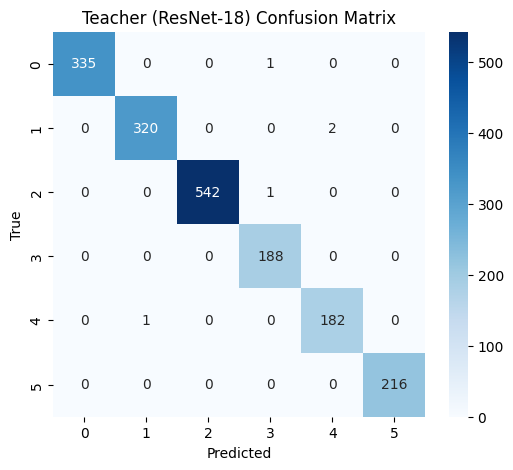

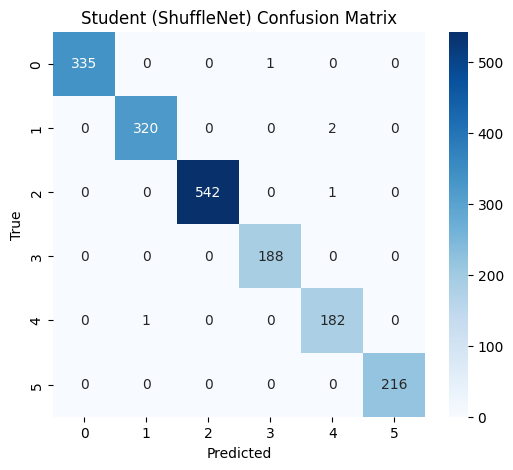

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_cm(labels, preds, title):
    cm = confusion_matrix(labels, preds)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES,
                yticklabels=CLASS_NAMES)
    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()




plot_cm(t_labels, t_preds, "Teacher (ResNet-18) Confusion Matrix")
plot_cm(s_labels, s_preds, "Student (ShuffleNet) Confusion Matrix")

In [9]:
from thop import profile
import torch

dummy = torch.randn(1, 3, 224, 224).to(device)

teacher_flops, teacher_params = profile(teacher, inputs=(dummy,))
student_flops, student_params = profile(student, inputs=(dummy,))

print("\n📌 Model Complexity")
print(f"Teacher FLOPs : {teacher_flops/1e9:.3f} GFLOPs")
print(f"Student FLOPs : {student_flops/1e9:.3f} GFLOPs")

print(f"Teacher Params: {teacher_params/1e6:.3f} M")
print(f"Student Params: {student_params/1e6:.3f} M")

[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register count_adap_avgpool() for <class 'torch.nn.modules.pooling.AdaptiveAvgPool2d'>.
[INFO] Register count_linear() for <class 'torch.nn.modules.linear.Linear'>.
[INFO] Register count_convNd() for <class 'torch.nn.modules.conv.Conv2d'>.
[INFO] Register count_normalization() for <class 'torch.nn.modules.batchnorm.BatchNorm2d'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.activation.ReLU'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.container.Sequential'>.
[INFO] Register zero_ops() for <class 'torch.nn.modules.pooling.MaxPool2d'>.
[INFO] Register count_adap_avg

In [10]:
import time
import numpy as np

def measure_latency(model, runs=100):
    model.eval()
    dummy = torch.randn(1,3,224,224).to(device)

    # warmup
    for _ in range(20):
        _ = model(dummy)

    torch.cuda.synchronize()
    times = []

    for _ in range(runs):
        start = torch.cuda.Event(enable_timing=True)
        end = torch.cuda.Event(enable_timing=True)

        start.record()
        _ = model(dummy)
        end.record()

        torch.cuda.synchronize()
        times.append(start.elapsed_time(end))

    return np.mean(times)




teacher_time = measure_latency(teacher)
student_time = measure_latency(student)

print(f"Teacher Latency: {teacher_time:.2f} ms")
print(f"Student Latency: {student_time:.2f} ms")

Teacher Latency: 3.41 ms
Student Latency: 9.16 ms


In [11]:
teacher_fps = 1000 / teacher_time
student_fps = 1000 / student_time

print(f"Teacher (ResNet 18) FPS: {teacher_fps:.2f}")
print(f"Student (ShuffleNet) FPS: {student_fps:.2f}")

Teacher (ResNet 18) FPS: 293.04
Student (ShuffleNet) FPS: 109.21


In [12]:
print("GPU Memory (MB):", torch.cuda.max_memory_allocated() / 1024**2)

GPU Memory (MB): 1003.978515625


In [13]:
from torch.profiler import profile, ProfilerActivity

dummy = torch.randn(1,3,224,224).to(device)

with profile(
    activities=[ProfilerActivity.CPU, ProfilerActivity.CUDA],
    record_shapes=True
) as prof:

    _ = student(dummy)

print(prof.key_averages().table(sort_by="cuda_time_total"))

/usr/local/lib/python3.12/dist-packages/torch/profiler/profiler.py:217: UserWarning: Warning: Profiler clears events at the end of each cycle.Only events from the current cycle will be reported.To keep events across cycles, set acc_events=True.
  _warn_once(


-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                                   Name    Self CPU %      Self CPU   CPU total %     CPU total  CPU time avg     Self CUDA   Self CUDA %    CUDA total  CUDA time avg    # of Calls  
-------------------------------------------------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  ------------  
                                           aten::conv2d         0.72%     208.320us        32.05%       9.282ms     154.695us       0.000us         0.00%       1.041ms      17.349us            60  
                                      aten::convolution         2.11%     610.555us        31.33%       9.073ms     151.223us       0.000us         0.00%       1.041ms      17.349us            60  
         

In [15]:
import json

results = {
    "teacher_accuracy": float(t_acc),
    "student_accuracy": float(s_acc),
    "teacher_flops": float(teacher_flops),
    "student_flops": float(student_flops),
    "teacher_params": float(teacher_params),
    "student_params": float(student_params),
    "teacher_latency_ms": float(teacher_time),
    "student_latency_ms": float(student_time),
    "teacher_fps": float(teacher_fps),
    "student_fps": float(student_fps),
}

with open("/kaggle/working/results.json", "w") as f:
    json.dump(results, f, indent=4)

print(" Results saved to results.json")

 Results saved to results.json


In [16]:
print("\n================ FINAL COMPARISON ================")
print(f"{'Metric':<20} {'Teacher':>10} {'Student':>10}")
print("-"*45)

print(f"{'Accuracy':<20} {t_acc:>10.4f} {s_acc:>10.4f}")
print(f"{'FLOPs (G)':<20} {teacher_flops/1e9:>10.3f} {student_flops/1e9:>10.3f}")
print(f"{'Params (M)':<20} {teacher_params/1e6:>10.3f} {student_params/1e6:>10.3f}")
print(f"{'Latency (ms)':<20} {teacher_time:>10.2f} {student_time:>10.2f}")
print(f"{'FPS':<20} {teacher_fps:>10.2f} {student_fps:>10.2f}")


================ FINAL COMPARISON ================
Metric                  Teacher    Student
---------------------------------------------
Accuracy                 0.9972     0.9972
FLOPs (G)                 1.824      0.164
Params (M)               11.180      1.792
Latency (ms)               3.41       9.16
FPS                      293.04     109.21
